# ResNet56 en CIFAR-10

Notebook para implementar y entrenar una **ResNet56** desde cero en CIFAR-10 usando PyTorch y tasa de aprendizaje fija.

## Imports y configuracion

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
import torch.nn.functional as F
from torchvision import datasets, transforms as T

# Reproducibilidad basica
torch.manual_seed(0)
np.random.seed(0)

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = False

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

Dispositivo: cuda


## Dataset y DataLoaders (CIFAR-10)

In [3]:
BATCH_SIZE = 128
VAL_SIZE = 5000
TEST_SIZE = 5000
NUM_WORKERS = 2

# Ruta local al dataset (usa la carpeta existente del proyecto)
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

candidate_1 = project_root / "data" / "Databases" / "cifar-10-batches-py"
candidate_2 = project_root / "data"
CIFAR_ROOT = candidate_1 if candidate_1.exists() else candidate_2
print("CIFAR root:", CIFAR_ROOT)

transform_train = T.Compose([
    T.RandomHorizontalFlip(p=0.3),
    T.ColorJitter(brightness=0.1, contrast=0.1, hue=0.05),
    T.RandomApply([T.RandomRotation(10), T.Resize(40), T.CenterCrop(32)], p=0.1),
    T.ToTensor(),
    T.Normalize([0.491, 0.482, 0.447], [0.247, 0.243, 0.262]),
])

transform_eval = T.Compose([
    T.ToTensor(),
    T.Normalize([0.491, 0.482, 0.447], [0.247, 0.243, 0.262]),
])

train_dataset = datasets.CIFAR10(root=str(CIFAR_ROOT), train=True, download=True, transform=transform_train)
test_full = datasets.CIFAR10(root=str(CIFAR_ROOT), train=False, download=True, transform=transform_eval)

val_dataset, test_dataset = random_split(
    test_full,
    [VAL_SIZE, TEST_SIZE],
    generator=torch.Generator().manual_seed(0),
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

CIFAR root: /content/data


100%|██████████| 170M/170M [00:02<00:00, 73.4MB/s] 


Train batches: 391 | Val batches: 40 | Test batches: 40


Clases: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


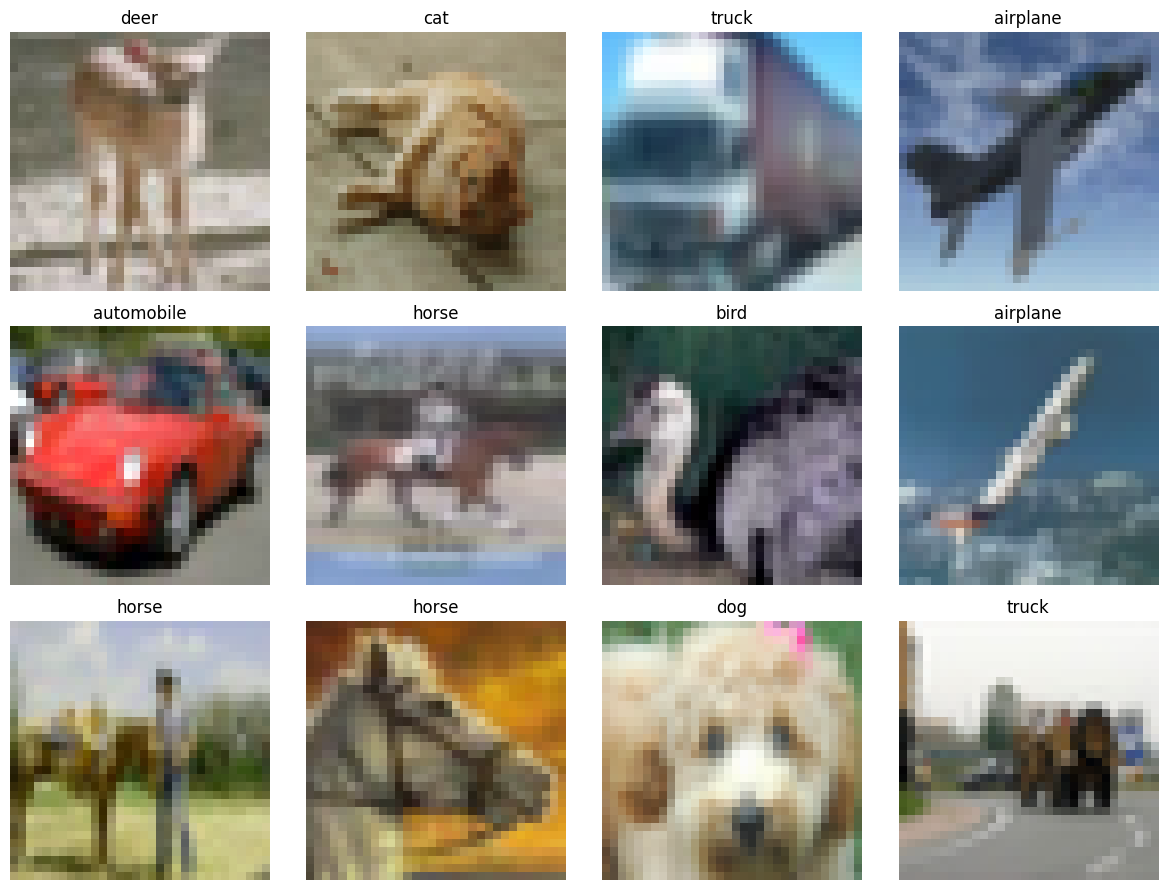

In [4]:
classes = train_dataset.classes
print("Clases:", classes)

def show_batch(loader, n=12):
    x, y = next(iter(loader))
    x = x[:n]
    y = y[:n]

    # Desnormalizacion para visualizar
    mean = torch.tensor([0.491, 0.482, 0.447]).view(1, 3, 1, 1)
    std = torch.tensor([0.247, 0.243, 0.262]).view(1, 3, 1, 1)
    x_vis = (x * std + mean).clamp(0, 1)

    cols = 4
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(12, 3 * rows))
    for i in range(n):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(np.transpose(x_vis[i].numpy(), (1, 2, 0)))
        plt.title(classes[y[i].item()])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_batch(train_loader, n=12)

## ResNet56

In [5]:
def conv3x3(in_channels, out_channels, stride=1):
    return nn.Conv2d(in_channels, out_channels, kernel_size=3, 
                     stride=stride, padding=1, bias=False)


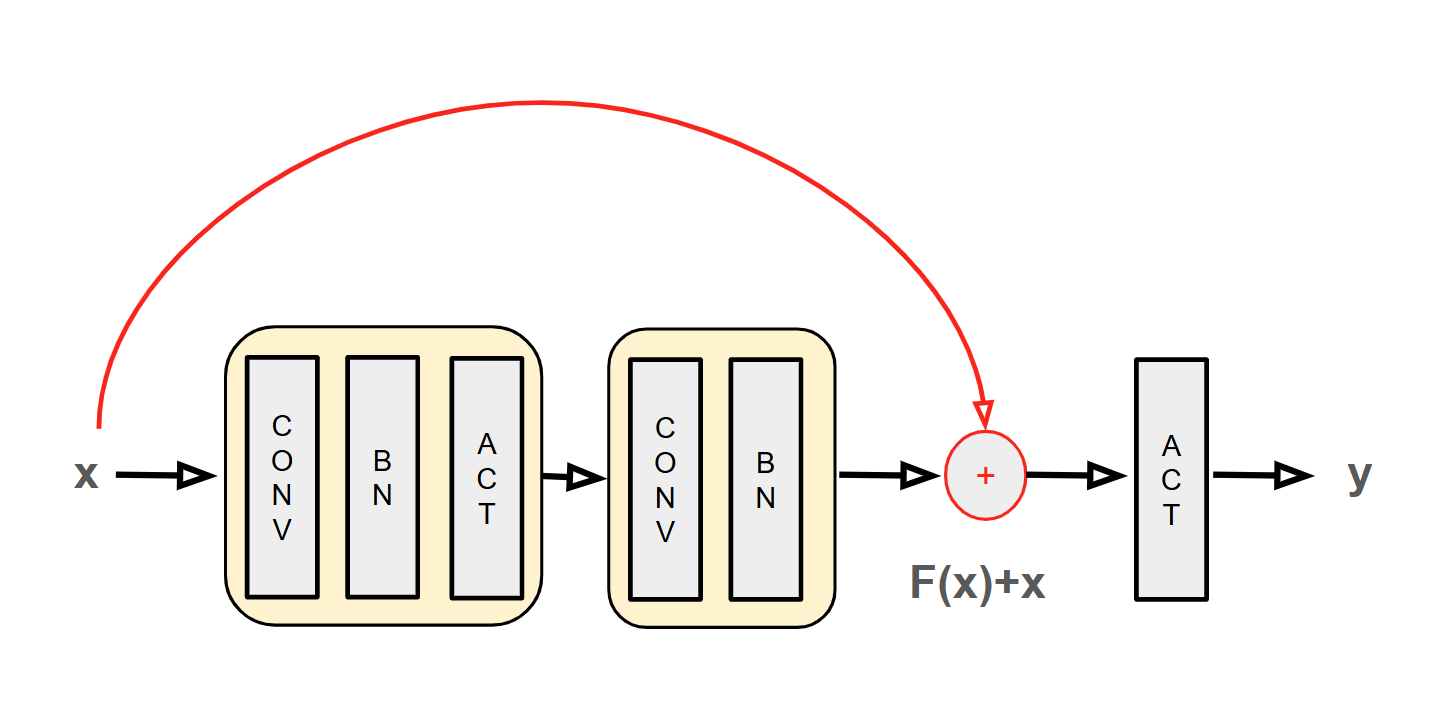

In [6]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, change_size=False):
        super().__init__()
        self.conv1 = conv3x3(in_channels, out_channels, stride=stride)
        self.bn1 =  nn.BatchNorm2d(out_channels)

        self.conv2 = conv3x3(out_channels, out_channels, stride=1)
        self.bn2 =  nn.BatchNorm2d(out_channels)

        if change_size:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )
            
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity =  self.shortcut(x)
        out1 = F.relu(self.bn1(self.conv1(x)))
        out2 = self.bn2(self.conv2(out1))
        out3 = out2 + identity
        return F.relu(out3)

### Como construir una ResNet para CIFAR-10 (regla $6n+2$)

Para CIFAR-10 se usa una variante de ResNet con bloques residuales basicos de dos convoluciones $3\times3$.

La red se organiza asi:

1. **Stem inicial**  
Convolucion $3\times3$ con 16 filtros sobre entrada $32\times32$.

2. **Tres etapas residuales**  
Cada etapa tiene $n$ bloques residuales, y cada bloque tiene 2 convoluciones $3\times3$:
- Etapa 1: mapa $32\times32$, 16 filtros  
- Etapa 2: mapa $16\times16$, 32 filtros (downsampling con stride=2 en el primer bloque)  
- Etapa 3: mapa $8\times8$, 64 filtros (downsampling con stride=2 en el primer bloque)

3. **Cabeza de clasificacion**  
Global Average Pooling + capa fully connected a 10 clases.

---

### Conteo correcto de capas

Hay dos formas comunes de contar:

- **Solo capas convolucionales:** $1 + 6n$  
(1 conv inicial + 3 etapas x $2n$ conv por etapa)

- **Capas ponderadas totales (conv + FC):** $6n + 2$

Para **ResNet56**, $n=9$:
- Convolucionales: $1 + 6(9) = 55$
- Totales con FC: $55 + 1 = 56$

---

### Resumen de arquitectura

| Operación | Filtros / Neuronas | Stride | Tamaño Salida | Lógica del cambio |
| :--- | :---: | :---: | :---: | :--- |
| **Entrada** | 3 | - | $32 \times 32 \times 3$ | Imagen original (RGB). |
| **Stem (Conv1)** | 16 | 1 | $32 \times 32 \times 16$ | Capa inicial de extracción. |
| **Etapa 1** | 16 | 1 | $32 \times 32 \times 16$ | Se mantiene resolución y profundidad. |
| **Inicio Etapa 2** | 32 | 2 | $16 \times 16 \times 32$ | **Downsampling:** Mitad de tamaño, doble de filtros. |
| **Inicio Etapa 3** | 64 | 2 | $8 \times 8 \times 64$ | **Downsampling:** Mitad de tamaño, doble de filtros. |
| **Global Avg Pool** | 64 | - | $1 \times 1 \times 64$ | Colapsa dimensiones espaciales a un vector. |
| **Fully Connected** | 10 | - | 10 | Clasificación final (10 clases). |

In [7]:
class ResNet6nPlus2(nn.Module):
    """ResNet de profundidad 56 para CIFAR-10: profundidad = 6n + 2 con n=9."""
    def __init__(self, num_classes=10, n=9):
        super().__init__()
        ## h= 32, w=32
        self.conv1 = conv3x3(3, 16, stride = 1)
        self.bn1 = nn.BatchNorm2d(16)

        self.stage1 = self.create_stage(16, 16, n_blocks=n, stride=1)
        
        self.stage2 = self.create_stage(16, 32, n_blocks=n, stride=2)

        self.stage3 = self.create_stage(32, 64, n_blocks=n, stride=2)

        self.pool = nn.AdaptiveAvgPool2d((1,1))
        
        self.fc = nn.Linear(64,10)
        

    def create_stage(self, in_channels, out_channels, n_blocks, stride):
        change_size = in_channels != out_channels or stride != 1
        blocks = [
            ResidualBlock(in_channels, out_channels, stride=stride, change_size=change_size)
        ]
        for _ in range(n_blocks-1):
            blocks.append(
                ResidualBlock(out_channels, out_channels, stride=1, change_size=False)
            )
        return nn.Sequential(*blocks)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.pool(x)
        x = torch.flatten(x,1)
        return self.fc(x)


model_resnet56 = ResNet6nPlus2().to(device)

n_params = sum(p.numel() for p in model_resnet56.parameters())
print(f"Parametros totales: {n_params:,}")

Parametros totales: 855,866


## Funciones de entrenamiento y evaluacion

In [8]:
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
        x = x.to(device=device, dtype=torch.float32, non_blocking=True)
        y = y.to(device=device, dtype=torch.long, non_blocking=True)

        logits = model(x)
        loss = F.cross_entropy(logits, y)
        total_loss += loss.item() * y.size(0)

        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total


def train(model, train_loader, val_loader, optimizer, device, epochs=30, scheduler=None):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "lr": [],
    }

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        running_correct = 0
        running_total = 0

        for x, y in train_loader:
            x = x.to(device=device, dtype=torch.float32, non_blocking=True)
            y = y.to(device=device, dtype=torch.long, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss = F.cross_entropy(logits, y)
            loss.backward()
            optimizer.step()

            if scheduler is not None:
                scheduler.step()

            running_loss += loss.item() * y.size(0)
            running_correct += (logits.argmax(dim=1) == y).sum().item()
            running_total += y.size(0)

        train_loss = running_loss / running_total
        train_acc = running_correct / running_total
        val_loss, val_acc = evaluate(model, val_loader, device)
        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
            f"lr={current_lr:.6f}"
        )

    return history

## Entrenamiento 

In [9]:
epochs = 12

model_resnet56 = ResNet6nPlus2().to(device)

optimizer = torch.optim.SGD(model_resnet56.parameters(), lr=0.05, momentum=0.95, weight_decay=1e-4)

history = train(
    model=model_resnet56,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    epochs=epochs,
    scheduler=None,
)

Epoch 01/12 | train_loss=1.8378 train_acc=0.3165 | val_loss=1.5948 val_acc=0.3920 | lr=0.050000
Epoch 02/12 | train_loss=1.3826 train_acc=0.4980 | val_loss=1.2261 val_acc=0.5574 | lr=0.050000
Epoch 03/12 | train_loss=1.0942 train_acc=0.6084 | val_loss=1.1485 val_acc=0.5904 | lr=0.050000
Epoch 04/12 | train_loss=0.8998 train_acc=0.6822 | val_loss=0.8995 val_acc=0.6886 | lr=0.050000
Epoch 05/12 | train_loss=0.7603 train_acc=0.7338 | val_loss=0.8733 val_acc=0.7174 | lr=0.050000
Epoch 06/12 | train_loss=0.6739 train_acc=0.7664 | val_loss=0.6735 val_acc=0.7724 | lr=0.050000
Epoch 07/12 | train_loss=0.5932 train_acc=0.7942 | val_loss=0.6167 val_acc=0.7940 | lr=0.050000
Epoch 08/12 | train_loss=0.5437 train_acc=0.8117 | val_loss=0.5861 val_acc=0.7972 | lr=0.050000
Epoch 09/12 | train_loss=0.5067 train_acc=0.8248 | val_loss=0.5592 val_acc=0.8100 | lr=0.050000
Epoch 10/12 | train_loss=0.4630 train_acc=0.8379 | val_loss=0.5596 val_acc=0.8122 | lr=0.050000
Epoch 11/12 | train_loss=0.4369 train_ac

In [ ]:
model_resnet20 = ResNet6nPlus2(n=3).to(device)
model_resnet92 = ResNet6nPlus2(n=15).to(device)


## Curvas de entrenamiento y evaluacion final

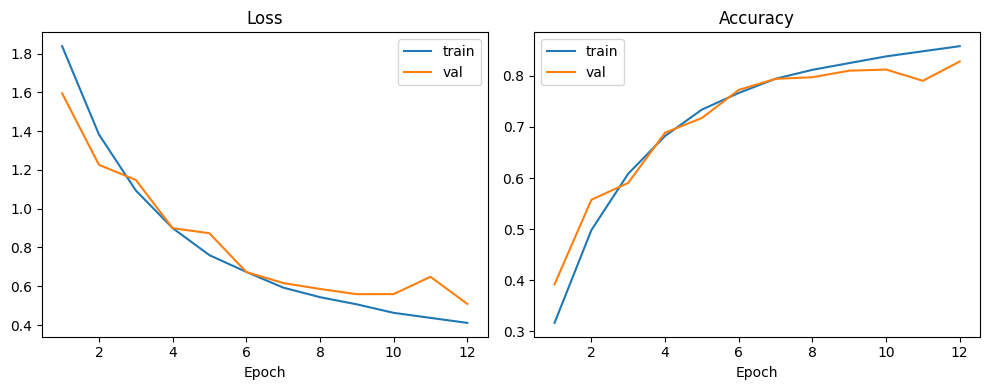

Test loss: 0.4880
Test accuracy: 0.8354


In [10]:
epochs_axis = np.arange(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_axis, history["train_loss"], label="train")
plt.plot(epochs_axis, history["val_loss"], label="val")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_axis, history["train_acc"], label="train")
plt.plot(epochs_axis, history["val_acc"], label="val")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
plt.show()

test_loss, test_acc = evaluate(model_resnet56, test_loader, device)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Test accuracy: 0.8354


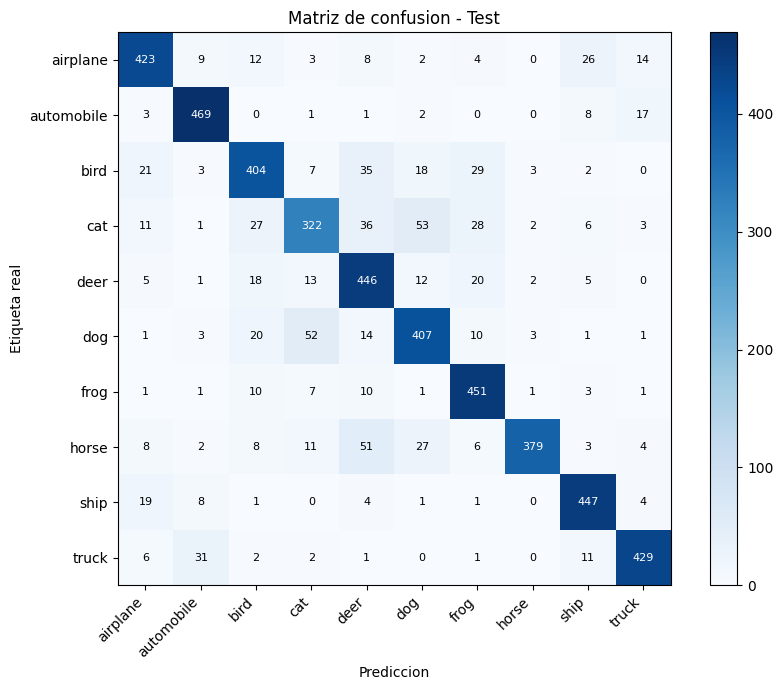

In [11]:
# Evaluacion final en test: accuracy y matriz de confusion
model_resnet56.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device=device, dtype=torch.float32, non_blocking=True)
        y = y.to(device=device, dtype=torch.long, non_blocking=True)

        logits = model_resnet56(x)
        preds = logits.argmax(dim=1)

        all_preds.append(preds.cpu())
        all_targets.append(y.cpu())

all_preds = torch.cat(all_preds)
all_targets = torch.cat(all_targets)

test_accuracy = (all_preds == all_targets).float().mean().item()
print(f"Test accuracy: {test_accuracy:.4f}")

# Matriz de confusion (sin dependencias externas)
num_classes = len(classes)
cm = torch.zeros((num_classes, num_classes), dtype=torch.int64)
for t, p in zip(all_targets, all_preds):
    cm[t.long(), p.long()] += 1

plt.figure(figsize=(9, 7))
plt.imshow(cm.numpy(), interpolation="nearest", cmap="Blues")
plt.title("Matriz de confusion - Test")
plt.colorbar()

tick_marks = np.arange(num_classes)
plt.xticks(tick_marks, classes, rotation=45, ha="right")
plt.yticks(tick_marks, classes)
plt.xlabel("Prediccion")
plt.ylabel("Etiqueta real")

# Mostrar valores dentro de la matriz
thresh = cm.max().item() / 2 if cm.max().item() > 0 else 0
for i in range(num_classes):
    for j in range(num_classes):
        value = cm[i, j].item()
        plt.text(
            j,
            i,
            f"{value}",
            ha="center",
            va="center",
            color="white" if value > thresh else "black",
            fontsize=8,
        )

plt.tight_layout()
plt.show()